# 02 — EDA: Energy Grid Demand

Exploratory analysis of hourly grid demand (EIA, PJM balancing authority)
before moving to feature engineering. Mirrors `01_eda_ridership.ipynb`.

Run `ingestion/energy/fetch_eia_demand.py` first to produce the input file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/raw/energy/eia_demand_pjm.parquet")
df.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2020-01-01 00:00:00,PJM,"PJM Interconnection, LLC",D,Demand,96028.0,megawatthours
1,2020-01-01 01:00:00,PJM,"PJM Interconnection, LLC",D,Demand,93365.0,megawatthours
2,2020-01-01 02:00:00,PJM,"PJM Interconnection, LLC",D,Demand,90573.0,megawatthours
3,2020-01-01 03:00:00,PJM,"PJM Interconnection, LLC",D,Demand,87907.0,megawatthours
4,2020-01-01 04:00:00,PJM,"PJM Interconnection, LLC",D,Demand,85226.0,megawatthours


In [2]:
df.sort_values('value', ascending=False).head(5)

,period,respondent,respondent-name,type,type-name,value,value-units
15772,2021-10-19 04:00:00,PJM,"PJM Interconnection, LLC",D,Demand,2.147480e+09,megawatthours
15771,2021-10-19 03:00:00,PJM,"PJM Interconnection, LLC",D,Demand,1.527760e+09,megawatthours
15773,2021-10-19 05:00:00,PJM,"PJM Interconnection, LLC",D,Demand,4.310440e+08,megawatthours
4936,2020-07-24 16:00:00,PJM,"PJM Interconnection, LLC",D,Demand,2.626510e+05,megawatthours
5925,2020-09-03 21:00:00,PJM,"PJM Interconnection, LLC",D,Demand,2.508250e+05,megawatthours


In [3]:
# PJM's actual max hourly demand is roughly 165,000 MWh historically.
# Anything wildly beyond that is a data error, not a real demand spike.
df_clean = df[df['value'] < 300_000].copy()
print(f"Dropped {len(df) - len(df_clean)} rows as outliers")

Dropped 96 rows as outliers


### 1. Date range and basic shape

In [4]:
print(df["period"].min(), "to", df["period"].max())
print(df.shape)
df.dtypes

2020-01-01 00:00:00 to 2024-01-01 23:00:00
(35087, 7)


period             datetime64[us]
respondent                    str
respondent-name               str
type                          str
type-name                     str
value                     float64
value-units                   str
dtype: object

### 2. Missing values / reporting gaps

In [5]:
df["value"].isna().sum(), df["value"].isna().mean()

(np.int64(93), np.float64(0.0026505543363638953))

### 3. Daily seasonality — hour-of-day pattern

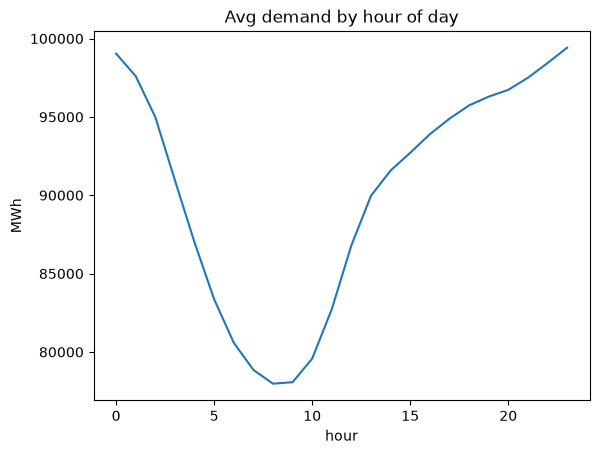

In [6]:
df_clean["hour"] = df_clean["period"].dt.hour
df_clean.groupby("hour")["value"].mean().plot(title="Avg demand by hour of day")
plt.ylabel("MWh")
plt.show()

### 4. Weekly seasonality — day-of-week pattern

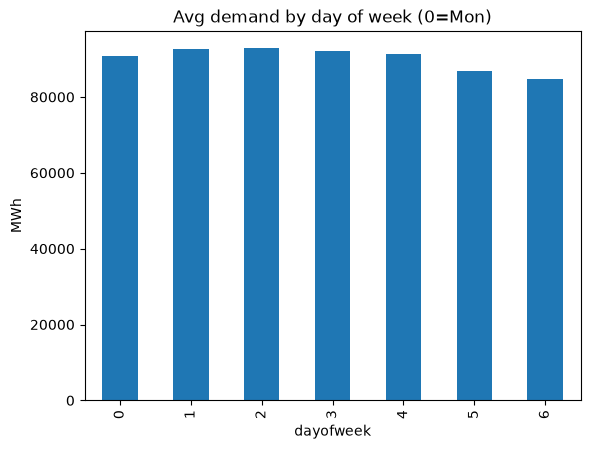

In [7]:
df_clean["dayofweek"] = df_clean["period"].dt.dayofweek
df_clean.groupby("dayofweek")["value"].mean().plot(kind="bar", title="Avg demand by day of week (0=Mon)")
plt.ylabel("MWh")
plt.show()

### 5. Yearly / seasonal pattern (this is where weather sensitivity should show up — summer AC + winter heating peaks)

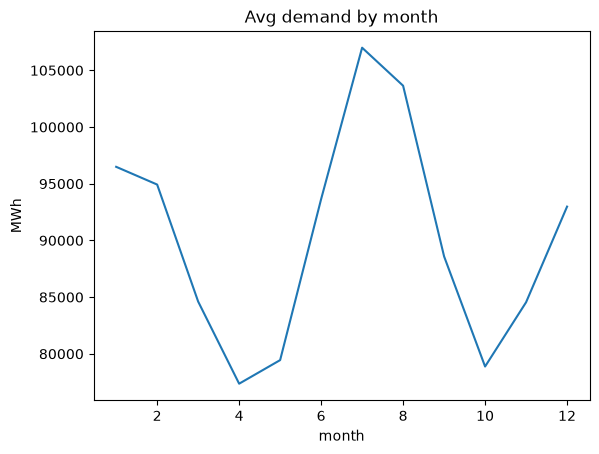

In [8]:
df_clean["month"] = df_clean["period"].dt.month
df_clean.groupby("month")["value"].mean().plot(title="Avg demand by month")
plt.ylabel("MWh")
plt.show()

### 6. Full time series — look for anomalies (extreme weather events, outages, holidays)

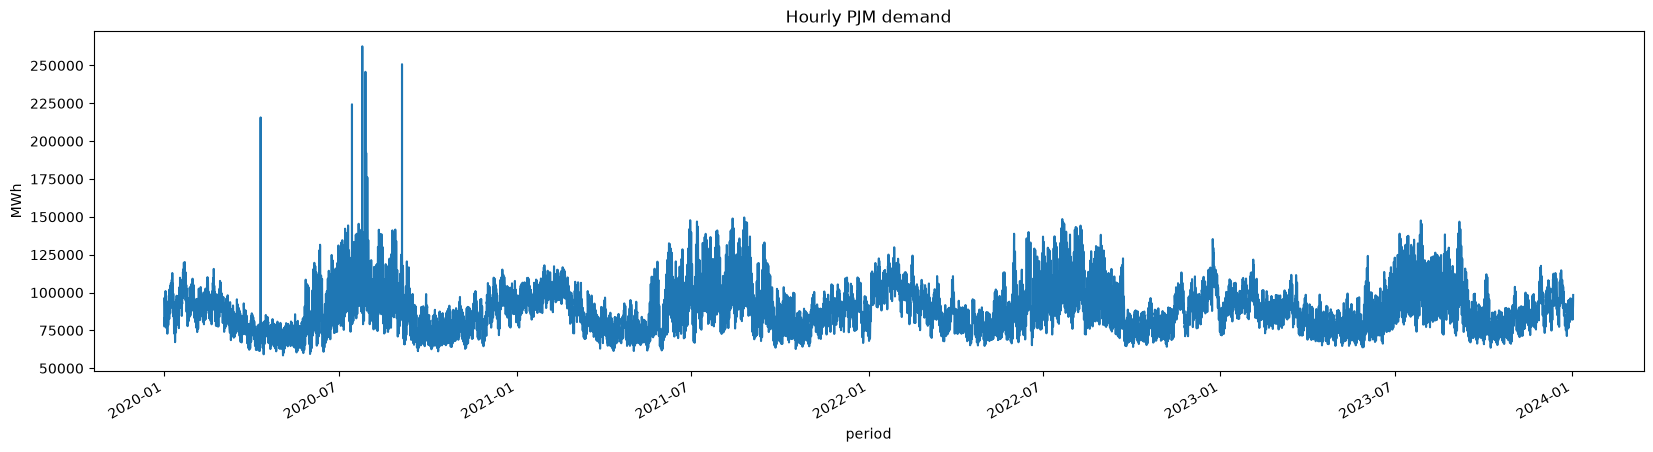

In [9]:
df_clean.set_index("period")["value"].plot(figsize=(20, 5), title="Hourly PJM demand")
plt.ylabel("MWh")
plt.show()

### 7. Cross-check against Chicago Energy Benchmarking (spatial layer)

Load the building-level benchmarking data and look at electricity use
aggregated by `community_area` — this becomes the neighborhood weighting
applied to the hourly PJM series in `features/energy/`.

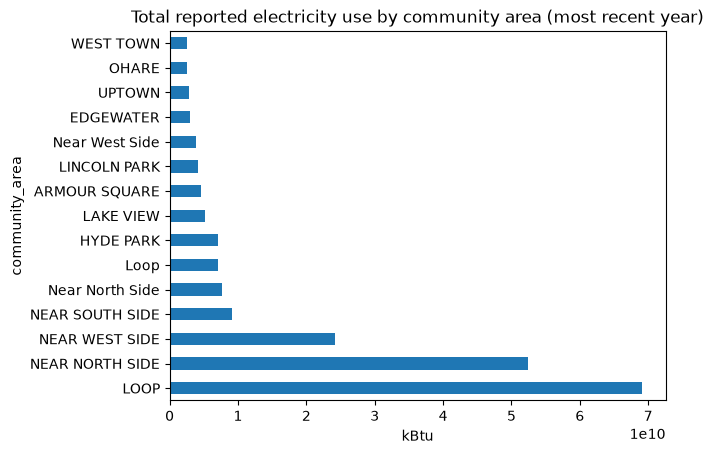

In [10]:
bench = pd.read_parquet("../data/raw/energy/chicago_energy_benchmarking.parquet")
bench["electricity_use_kbtu"] = pd.to_numeric(bench["electricity_use_kbtu"], errors="coerce")
bench.groupby("community_area")["electricity_use_kbtu"].sum().sort_values(ascending=False).head(15).plot(
    kind="barh", title="Total reported electricity use by community area (most recent year)"
)
plt.xlabel("kBtu")
plt.show()

---
**Do not move to feature engineering until you can answer:**
- What does demand look like by hour, day, and month?
- Where are the anomalies (heat waves, cold snaps, outages)?
- Which community areas dominate reported building electricity use, and does that plausibly track with population/density?